# Messy Mashup — Music Genre Classification

**Metric:** Macro F1 Score (10 genres, equal weight per class)  
**Core Challenge:** Train on clean stems → Predict on noisy mashups (distribution shift)  
**Key Strategy:** Augment training data to simulate test conditions

| Milestone | Goal | Expected F1 |
|-----------|------|-------------|
| 1 | EDA + Baseline Submission | ~0.10 (random) |
| 2 | Classical ML (MFCC + LightGBM) | 0.40–0.60 |
| 3 | CNN on Mel Spectrograms | 0.60–0.80 |
| 4 | Pretrained Transformers | 0.80+ |
| 5 | Ensemble + Final Submission | Best score |

---
## Setup & Imports

In [2]:
import sys
sys.path.insert(0, '..')

import os
import random
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from tqdm.notebook import tqdm
from datetime import datetime

plt.style.use('dark_background')
sns.set_palette('husl')

# ── Project config ────────────────────────────────────────────────────────────
from src import config
from src.config import set_seed, get_device

set_seed(config.SEED)

print(f'Python: {sys.version.split()[0]}')
print(f'NumPy: {np.__version__}')
print(f'Genres ({config.NUM_CLASSES}): {config.GENRES}')
print(f'Metric: Macro F1')

Python: 3.12.12
NumPy: 2.4.2
Genres (10): ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Metric: Macro F1


---
# MILESTONE 1 — EDA & Baseline Submission

### 1.1 Dataset Structure

In [2]:
# Build genre → song dirs index
song_dirs = {}
for genre in config.GENRES:
    genre_dir = config.GENRES_DIR / genre
    dirs = sorted([d for d in genre_dir.iterdir() if d.is_dir()])
    song_dirs[genre] = dirs

print('Dataset summary:')
print(f'  Genres: {len(song_dirs)}')
print(f'  Songs per genre: {[len(v) for v in song_dirs.values()]}')
print(f'  Total songs: {sum(len(v) for v in song_dirs.values())}')
print(f'  Stems per song: {len(config.STEM_NAMES)} ({config.STEM_NAMES})')
print(f'  Total stem files: {sum(len(v) for v in song_dirs.values()) * len(config.STEM_NAMES)}')

# Test set
test_df = pd.read_csv(config.TEST_CSV)
mashup_files = sorted(config.MASHUPS_DIR.glob('*.wav'))
esc50_files = sorted(config.ESC50_AUDIO_DIR.glob('*.wav'))
print(f'\n  Test mashups: {len(mashup_files)}')
print(f'  ESC-50 noise clips: {len(esc50_files)}')

Dataset summary:
  Genres: 10
  Songs per genre: [100, 100, 100, 100, 100, 100, 100, 100, 100, 100]
  Total songs: 1000
  Stems per song: 4 (['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav'])
  Total stem files: 4000

  Test mashups: 3020
  ESC-50 noise clips: 2000


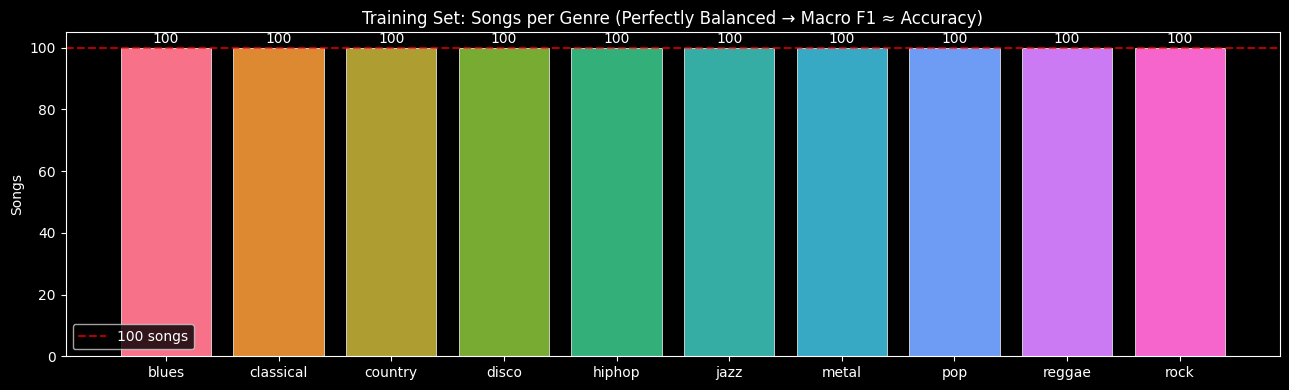

In [3]:
# Class distribution plot
genre_counts = {g: len(d) for g, d in song_dirs.items()}

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(genre_counts.keys(), genre_counts.values(),
              color=sns.color_palette('husl', 10), edgecolor='white', linewidth=0.5)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.7, label='100 songs')
ax.set_ylabel('Songs')
ax.set_title('Training Set: Songs per Genre (Perfectly Balanced → Macro F1 ≈ Accuracy)')
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

### 1.2 Audio Property Analysis

Sampling audio durations from training stems...


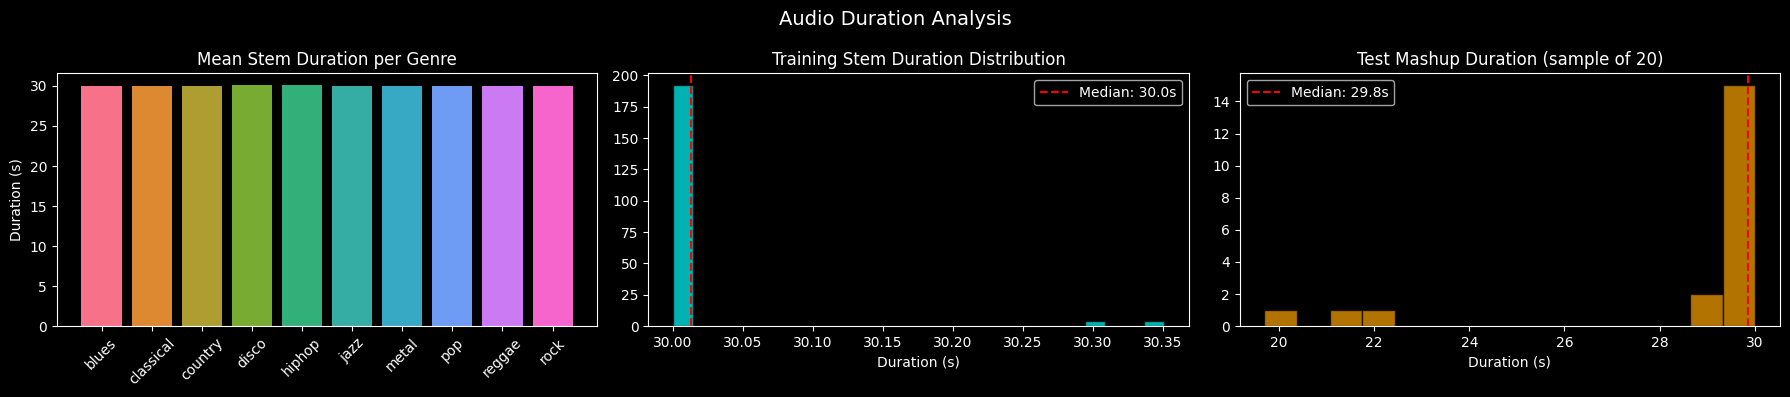

Train stems — mean: 30.0s, median: 30.0s
Test mashups — mean: 28.5s, median: 29.8s


In [4]:
# Sample duration info (5 songs × 4 stems per genre)
print('Sampling audio durations from training stems...')
dur_data = []
for genre in config.GENRES:
    sample = random.sample(song_dirs[genre], min(5, len(song_dirs[genre])))
    for song_dir in sample:
        for stem in config.STEM_NAMES:
            p = song_dir / stem
            if not p.exists():
                p = song_dir / 'others.wav'
            if p.exists():
                try:
                    info = sf.info(str(p))
                    dur_data.append({'genre': genre, 'stem': stem,
                                     'duration_s': info.duration, 'sr': info.samplerate})
                except:
                    pass

dur_df = pd.DataFrame(dur_data)

# Mashup durations (20 samples)
mashup_durs = []
for mf in random.sample(mashup_files, min(20, len(mashup_files))):
    try:
        info = sf.info(str(mf))
        mashup_durs.append(info.duration)
    except:
        pass

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Training duration per genre
dur_per_genre = dur_df.groupby('genre')['duration_s'].mean().reindex(config.GENRES)
axes[0].bar(dur_per_genre.index, dur_per_genre.values, color=sns.color_palette('husl', 10))
axes[0].set_title('Mean Stem Duration per Genre')
axes[0].set_ylabel('Duration (s)')
axes[0].tick_params(axis='x', rotation=45)

# Training duration histogram
axes[1].hist(dur_df['duration_s'], bins=25, color='cyan', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Duration (s)')
axes[1].set_title('Training Stem Duration Distribution')
axes[1].axvline(dur_df['duration_s'].median(), color='red', linestyle='--',
                label=f'Median: {dur_df["duration_s"].median():.1f}s')
axes[1].legend()

# Test mashup duration
axes[2].hist(mashup_durs, bins=15, color='orange', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Duration (s)')
axes[2].set_title('Test Mashup Duration (sample of 20)')
axes[2].axvline(np.median(mashup_durs), color='red', linestyle='--',
                label=f'Median: {np.median(mashup_durs):.1f}s')
axes[2].legend()

plt.suptitle('Audio Duration Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Train stems — mean: {dur_df["duration_s"].mean():.1f}s, median: {dur_df["duration_s"].median():.1f}s')
print(f'Test mashups — mean: {np.mean(mashup_durs):.1f}s, median: {np.median(mashup_durs):.1f}s')

### 1.3 Mel Spectrogram Visualization

In [5]:
def load_audio(path, sr=config.SAMPLE_RATE, duration=10.0, offset=0.0):
    audio, _ = librosa.load(str(path), sr=sr, mono=True, duration=duration, offset=offset)
    return audio

def plot_melspec(audio, sr, title='', ax=None, add_colorbar=True):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, hop_length=512,
                                    x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title, fontsize=10)
    if add_colorbar:
        plt.colorbar(img, ax=ax, format='%+2.0f dB')
    return img

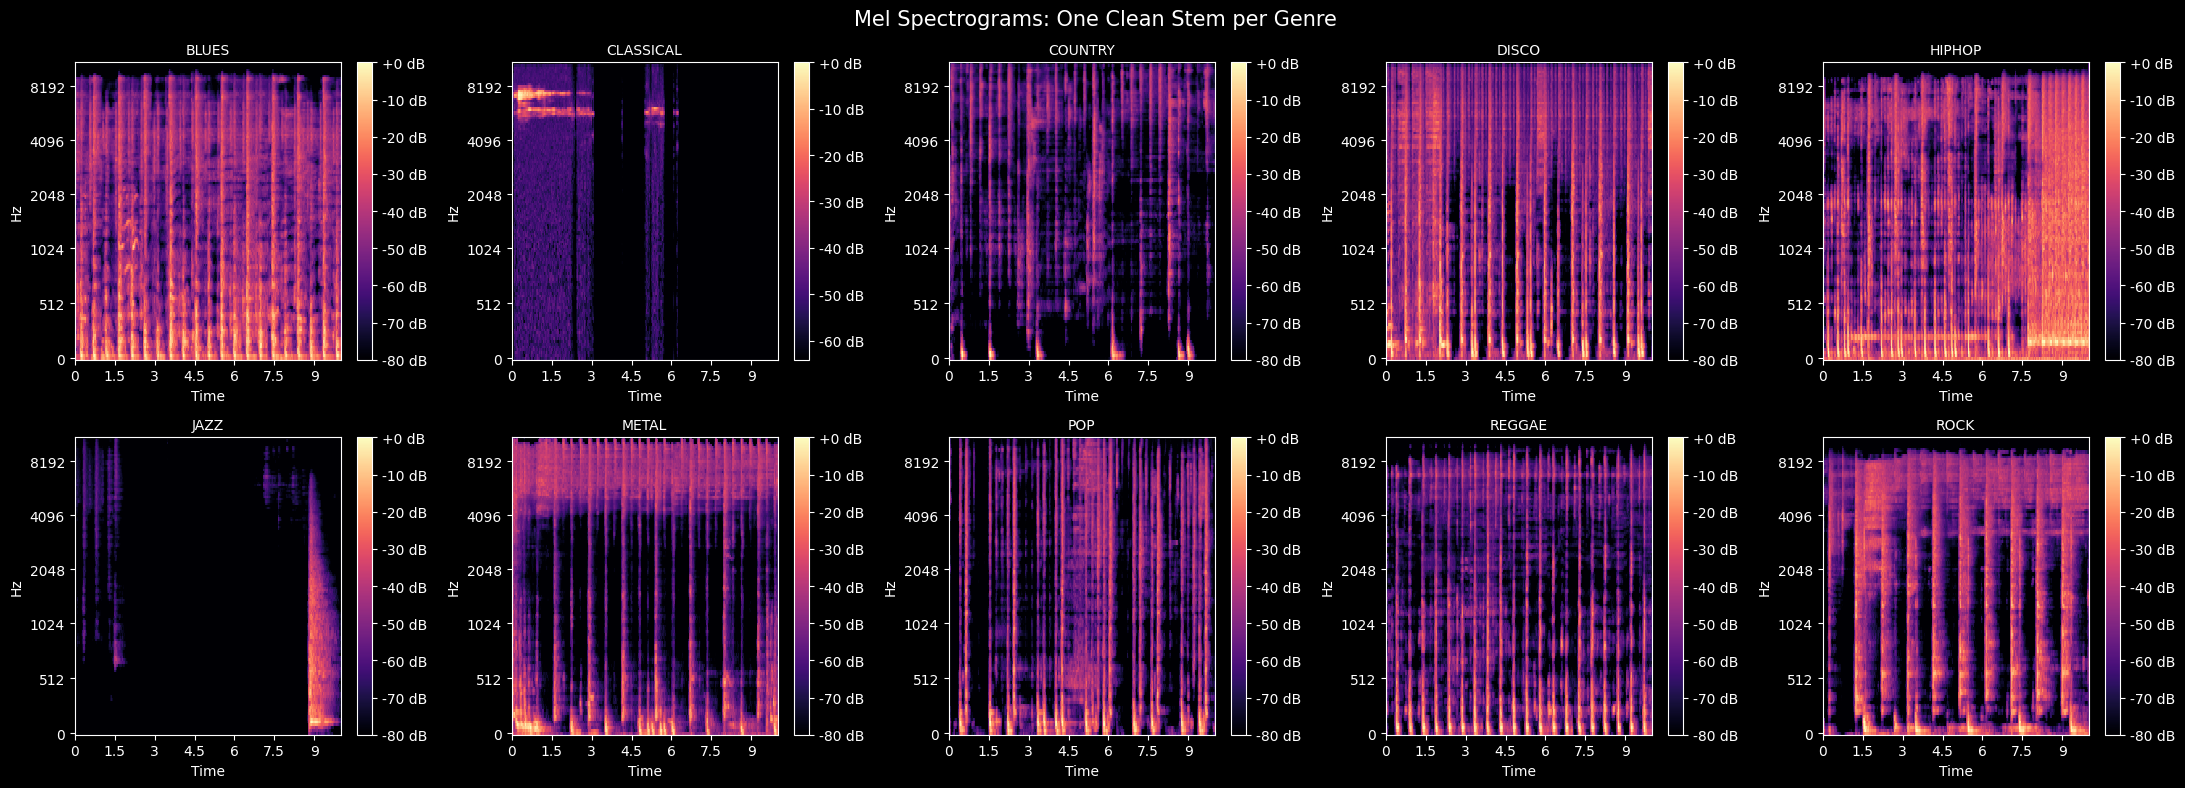

In [6]:
# One mel spec per genre
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, genre in enumerate(config.GENRES):
    stem_path = None
    for sname in config.STEM_NAMES:
        p = song_dirs[genre][0] / sname
        if p.exists():
            stem_path = p; break
    if stem_path:
        try:
            audio = load_audio(stem_path, duration=10.0)
            plot_melspec(audio, config.SAMPLE_RATE, title=genre.upper(), ax=axes[i])
        except Exception as e:
            axes[i].set_title(f'{genre} — FAILED')

plt.suptitle('Mel Spectrograms: One Clean Stem per Genre', fontsize=15)
plt.tight_layout()
plt.show()

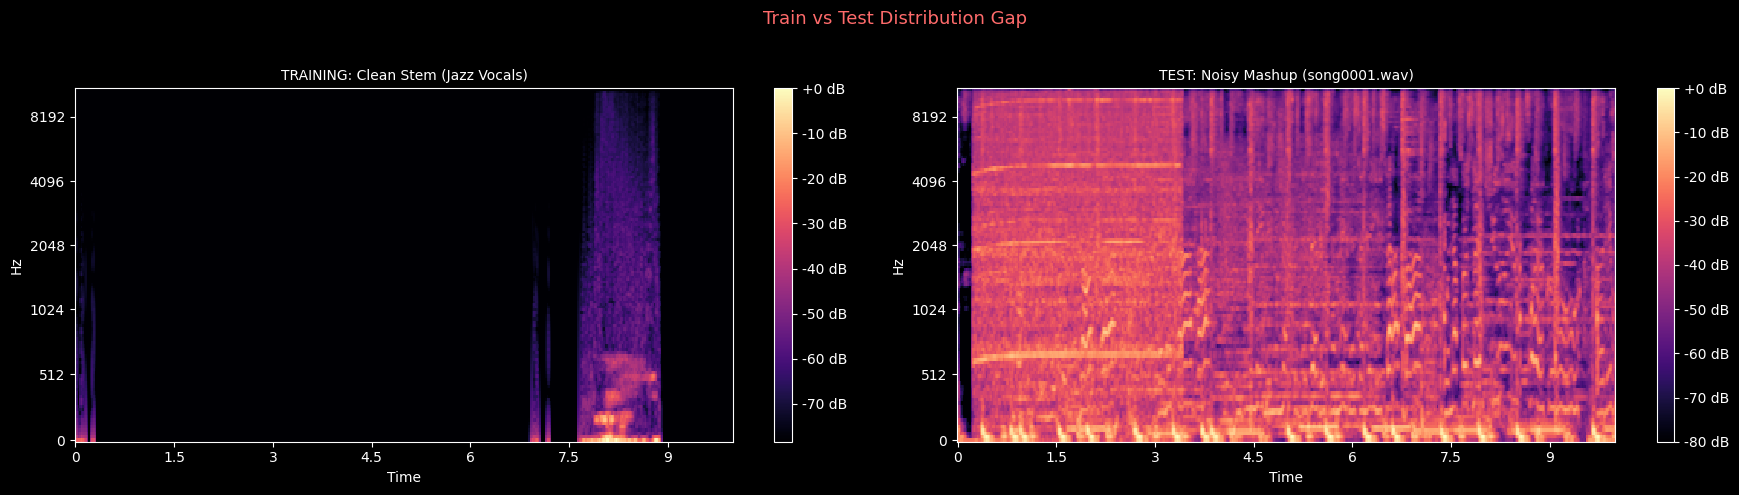

In [7]:
# ── THE CORE PROBLEM: Train/Test distribution gap ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Clean training stem
clean_p = song_dirs['jazz'][0] / config.STEM_NAMES[1]  # vocals
if not clean_p.exists():
    clean_p = song_dirs['jazz'][0] / config.STEM_NAMES[0]
clean_audio = load_audio(clean_p, duration=10.0)
plot_melspec(clean_audio, config.SAMPLE_RATE, 
             title='TRAINING: Clean Stem (Jazz Vocals)', ax=axes[0])

# Noisy test mashup
test_mashup_audio = load_audio(mashup_files[0], duration=10.0)
plot_melspec(test_mashup_audio, config.SAMPLE_RATE,
             title=f'TEST: Noisy Mashup ({mashup_files[0].name})', ax=axes[1])

plt.suptitle('Train vs Test Distribution Gap\n',
             fontsize=13, color='#FF6B6B')
plt.tight_layout()
plt.show()

### 1.4 ESC-50 Noise Analysis

ESC-50: 2000 clips, 50 categories, 40 clips each


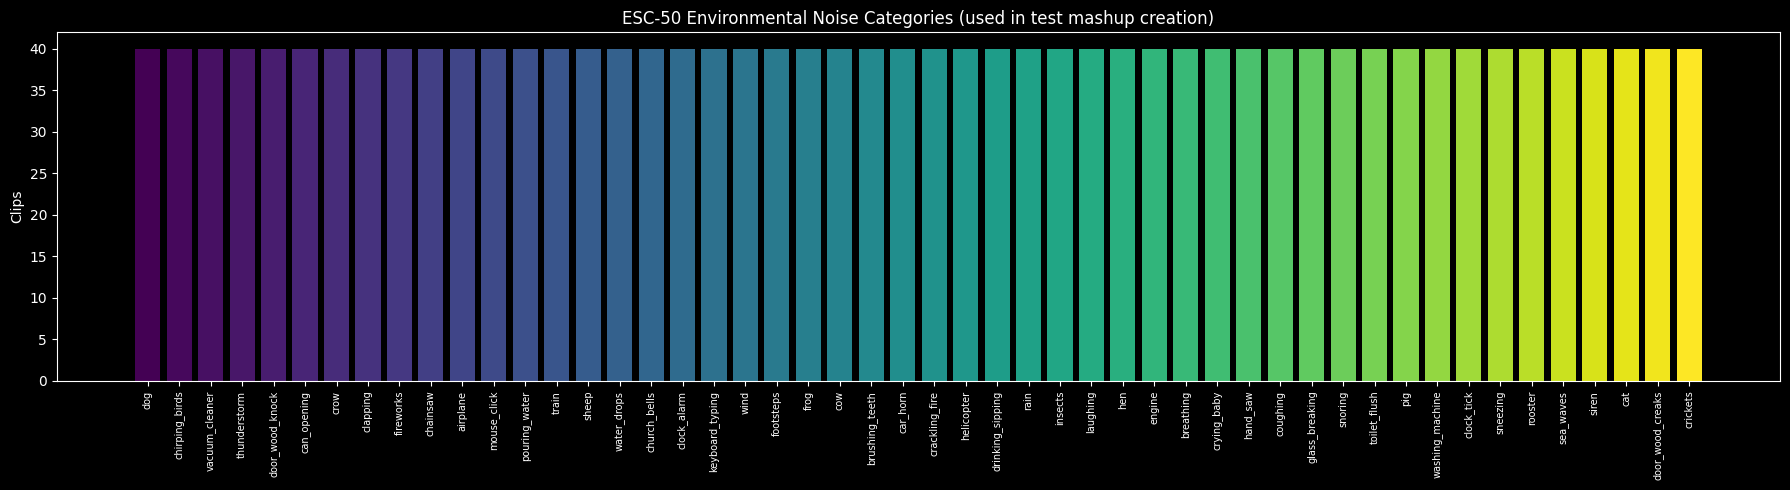

In [8]:
esc50_df = pd.read_csv(config.ESC50_META_CSV)
print(f'ESC-50: {len(esc50_df)} clips, {esc50_df["category"].nunique()} categories, 40 clips each')

fig, ax = plt.subplots(figsize=(18, 5))
cats = esc50_df['category'].value_counts()
ax.bar(range(len(cats)), cats.values, 
       color=plt.cm.viridis(np.linspace(0, 1, len(cats))))
ax.set_xticks(range(len(cats)))
ax.set_xticklabels(cats.index, rotation=90, fontsize=7)
ax.set_ylabel('Clips')
ax.set_title('ESC-50 Environmental Noise Categories (used in test mashup creation)')
plt.tight_layout()
plt.show()

### 1.5 Augmentation Demo: Clean Stem → Synthetic Mashup

Building stem index...
Synthetic mashup: genre=jazz, duration=10.0s


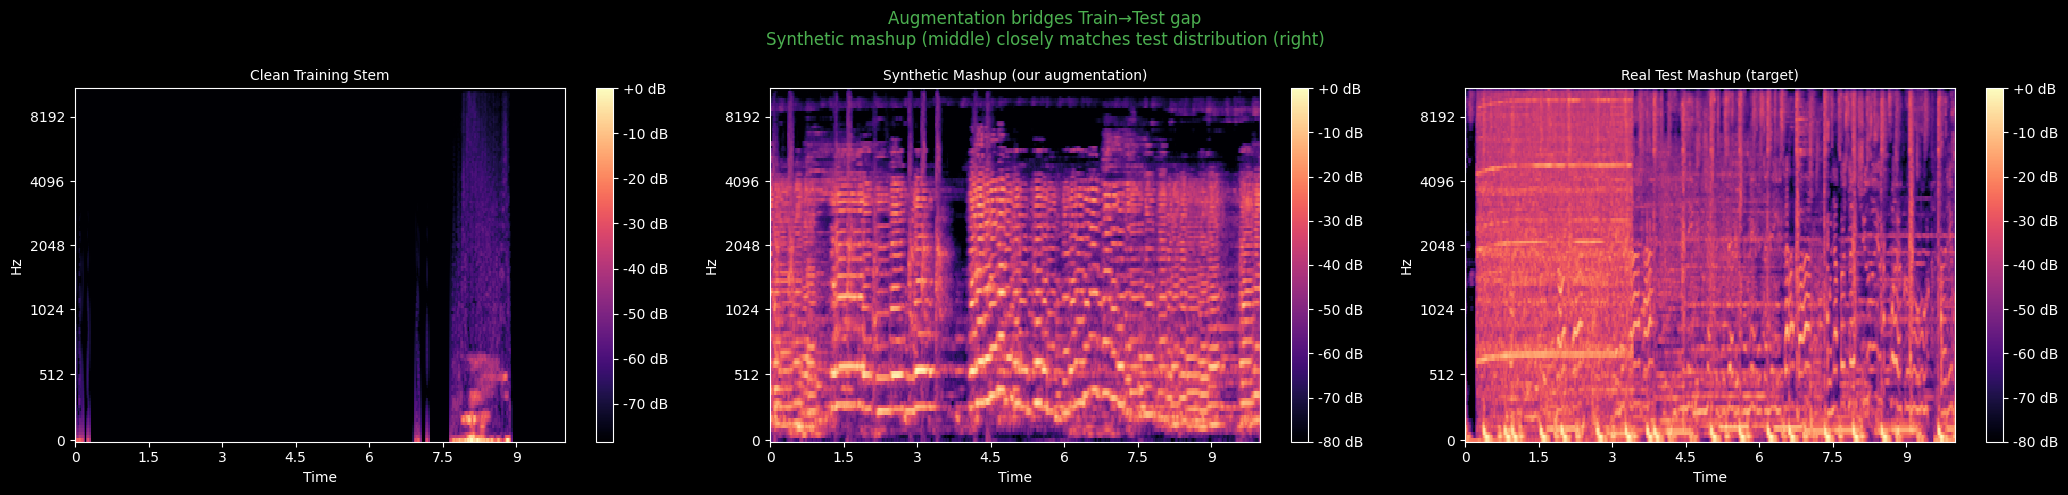

In [9]:
from src.augment import build_stem_index, split_songs_train_val, create_synthetic_mashup

print('Building stem index...')
stem_index = build_stem_index()

# Create a synthetic mashup
synth_audio, synth_genre = create_synthetic_mashup(
    genre='jazz', stem_index=stem_index,
    target_duration=10.0, add_noise=True, apply_tempo=True
)
print(f'Synthetic mashup: genre={synth_genre}, duration={len(synth_audio)/config.SAMPLE_RATE:.1f}s')

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# Clean stem
plot_melspec(clean_audio, config.SAMPLE_RATE, title='Clean Training Stem', ax=axes[0])

# Synthetic mashup (augmented)
plot_melspec(synth_audio, config.SAMPLE_RATE, title='Synthetic Mashup (our augmentation)', ax=axes[1])

# Real test mashup
plot_melspec(test_mashup_audio, config.SAMPLE_RATE, title='Real Test Mashup (target)', ax=axes[2])

plt.suptitle('Augmentation bridges Train→Test gap\n'
             'Synthetic mashup (middle) closely matches test distribution (right)', 
             fontsize=12, color='#4CAF50')
plt.tight_layout()
plt.show()

### 1.6 Baseline Submissions

In [10]:
test_df = pd.read_csv(config.TEST_CSV)
ids = test_df['id'].astype(str).str.zfill(4).tolist()
print(f'Test samples: {len(ids)}')

# Random baseline
random.seed(config.SEED)
random_sub = pd.DataFrame({'id': ids, 'genre': [random.choice(config.GENRES) for _ in ids]})
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
random_path = config.SUBMISSIONS_DIR / f'submission_{ts}_random.csv'
random_sub.to_csv(random_path, index=False)
print(f'Random baseline saved → {random_path}')
print(f'Expected Macro F1 ≈ 0.10')

# Verify format
assert list(random_sub.columns) == ['id', 'genre']
assert len(random_sub) == 3020
assert set(random_sub['genre']).issubset(set(config.GENRES))
print('✓ Format valid!')

Test samples: 3020
Random baseline saved → /Users/sanskar/dev/DL-GenAI-P/submissions/submission_20260224_095116_random.csv
Expected Macro F1 ≈ 0.10
✓ Format valid!


---
# MILESTONE 2 — Classical ML Baseline

**Approach:** Synthetic mashups → MFCC + chroma + spectral features → LightGBM  
**Expected F1:** 0.40–0.60

### 2.1 Feature Extraction

In [11]:
from src.features import extract_full_features

# Split songs into train/val
train_index, val_index = split_songs_train_val(
    stem_index, val_per_genre=config.VAL_SONGS_PER_GENRE, seed=config.SEED
)
print(f'Train songs: {sum(len(v) for v in train_index.values())}')
print(f'Val songs: {sum(len(v) for v in val_index.values())}')

# Show feature vector dimensions
dummy_audio = np.random.randn(config.CHUNK_SAMPLES).astype(np.float32)
dummy_feat = extract_full_features(dummy_audio)
print(f'Feature vector size: {dummy_feat.shape[0]}')

Train songs: 850
Val songs: 150
Feature vector size: 286


In [12]:
# ── Enhanced feature extraction (defined here for notebook self-containment) ──
# Adds tonnetz + ZCR + tempo to the base MFCC+chroma+spectral set
# Total: 240 (MFCC) + 24 (chroma) + 22 (spectral) + 12 (tonnetz) + 5 (ZCR+tempo) = 303

def extract_enhanced_features(audio, sr=config.SAMPLE_RATE):
    """
    303-dim feature vector for robust genre classification under noise.
    Defines all feature extraction inline for notebook self-containment.
    """
    from src.features import extract_mfcc_features, extract_chroma_features, extract_spectral_features
    
    mfcc_feat     = extract_mfcc_features(audio, sr)      # 240: MFCC mean/std + delta
    chroma_feat   = extract_chroma_features(audio, sr)    # 24:  chroma mean/std
    spectral_feat = extract_spectral_features(audio, sr)  # 24:  centroid/bandwidth/rolloff/contrast/rms
    
    # Tonnetz: tonal centroid — captures harmonic/key patterns, robust to mixing noise
    try:
        harmonic = librosa.effects.harmonic(audio)
        tonnetz  = librosa.feature.tonnetz(y=harmonic, sr=sr)   # (6, T)
        tonnetz_feat = np.concatenate([tonnetz.mean(axis=1), tonnetz.std(axis=1)])
    except Exception:
        tonnetz_feat = np.zeros(12, dtype=np.float32)
    
    # ZCR + tempo: captures noisiness and rhythmic structure
    try:
        zcr = librosa.feature.zero_crossing_rate(audio)
        tempo, _ = librosa.beat.beat_track(y=audio, sr=sr)
        onset_env = librosa.onset.onset_strength(y=audio, sr=sr)
        zcr_tempo_feat = np.array([zcr.mean(), zcr.std(), float(tempo),
                                    onset_env.mean(), onset_env.std()])
    except Exception:
        zcr_tempo_feat = np.zeros(5, dtype=np.float32)
    
    return np.concatenate([mfcc_feat, chroma_feat, spectral_feat,
                            tonnetz_feat, zcr_tempo_feat]).astype(np.float32)


def generate_ml_features(idx_split, n_samples, add_noise=True, split_name=''):
    """Generate synthetic mashups and extract enhanced ML features."""
    genres = list(idx_split.keys())
    n_per_genre = n_samples // len(genres)
    extra = n_samples % len(genres)
    X_list, y_list = [], []
    
    for i, genre in enumerate(genres):
        n = n_per_genre + (1 if i < extra else 0)
        for _ in tqdm(range(n), desc=f'{split_name} [{genre}]', leave=False):
            try:
                # apply_tempo=False: 26s/sample is too slow; augmentation done in feature space
                audio, _ = create_synthetic_mashup(genre, idx_split,
                                                    add_noise=add_noise, apply_tempo=False)
                feats = extract_enhanced_features(audio)
                X_list.append(feats)
                y_list.append(config.GENRE_TO_IDX[genre])
            except:
                pass
    
    X = np.nan_to_num(np.array(X_list, dtype=np.float32))
    y = np.array(y_list, dtype=np.int32)
    return X, y

# ── Config: 8000 train / 1000 val (up from 2000/500) ─────────────────────────
N_TRAIN_ML = 8000
N_VAL_ML   = 1000

cache_path = config.FEATURES_DIR / f'ml_enhanced_Tr{N_TRAIN_ML}_V{N_VAL_ML}.npz'

if cache_path.exists():
    print(f'Loading cached features: {cache_path}')
    data = np.load(cache_path)
    X_train, y_train = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'], data['y_val']
else:
    print(f'Generating features ({N_TRAIN_ML} train, {N_VAL_ML} val)...')
    t0 = time.time()
    X_train, y_train = generate_ml_features(train_index, N_TRAIN_ML, split_name='Train')
    X_val, y_val = generate_ml_features(val_index, N_VAL_ML, split_name='Val')
    print(f'Done in {time.time()-t0:.0f}s')
    np.savez(cache_path, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val)
    print(f'Cached to {cache_path}')

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}  (303 features)')
print(f'Label balance: {np.bincount(y_train)}')


Generating features (8000 train, 1000 val)...


Train [blues]:   0%|          | 0/800 [00:00<?, ?it/s]

Train [classical]:   0%|          | 0/800 [00:00<?, ?it/s]

Train [country]:   0%|          | 0/800 [00:00<?, ?it/s]

Train [disco]:   0%|          | 0/800 [00:00<?, ?it/s]

...

Val [metal]:   0%|          | 0/100 [00:00<?, ?it/s]

Val [pop]:   0%|          | 0/100 [00:00<?, ?it/s]

Val [reggae]:   0%|          | 0/100 [00:00<?, ?it/s]

Val [rock]:   0%|          | 0/100 [00:00<?, ?it/s]

Done in 5666s
Cached to /Users/sanskar/dev/DL-GenAI-P/outputs/features/ml_enhanced_Tr8000_V1000.npz
X_train: (8000, 303), X_val: (1000, 303)  (303 features)
Label balance: [800 800 800 800 800 800 800 800 800 800]


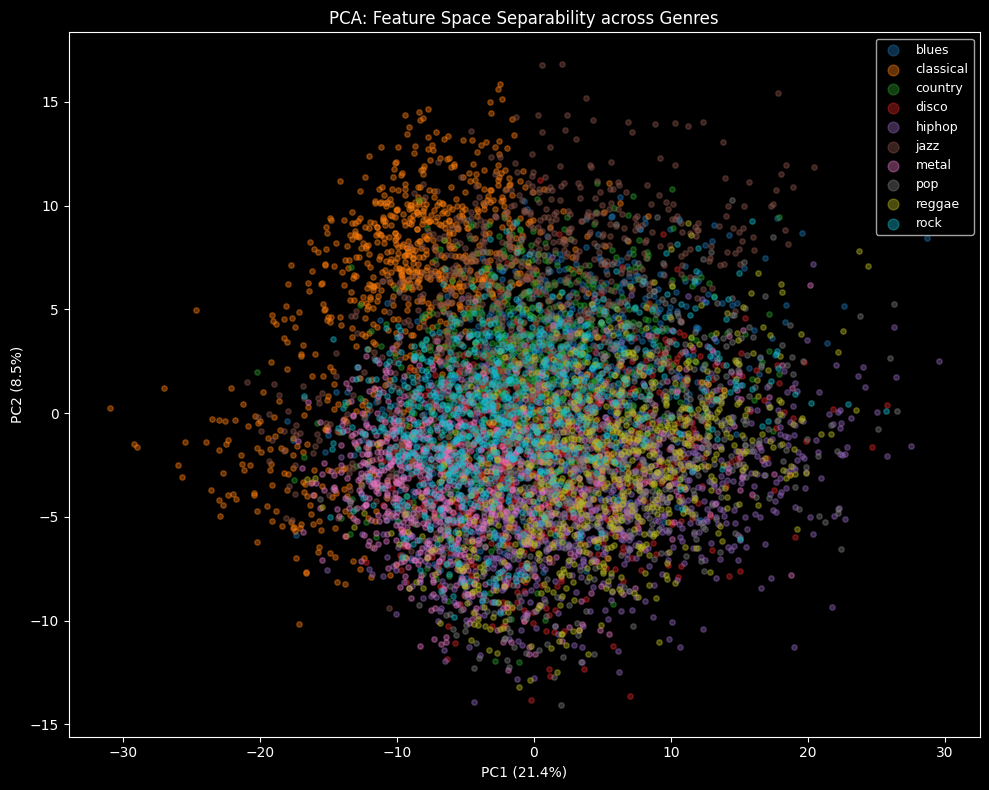

In [13]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_ml = StandardScaler()
X_tr_s = scaler_ml.fit_transform(X_train)
X_vl_s = scaler_ml.transform(X_val)

# PCA viz
pca = PCA(n_components=2, random_state=config.SEED)
X_pca = pca.fit_transform(X_tr_s)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i, genre in enumerate(config.GENRES):
    mask = y_train == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=genre, alpha=0.4, s=15, color=colors[i])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA: Feature Space Separability across Genres')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

### 2.2 Train Classifiers

In [14]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

def eval_model(model, X, y, name):
    preds = model.predict(X)
    f1 = f1_score(y, preds, average='macro')
    print(f'\n{name} — Macro F1: {f1:.4f}')
    print(classification_report(y, preds, target_names=config.GENRES, digits=3))
    return f1, preds

ml_results = {}  # store {model_name: (model, f1, preds)}

In [15]:
# Logistic Regression
lr = Pipeline([('scaler', StandardScaler()),
               ('clf', LogisticRegression(C=1.0, max_iter=2000,
                                          class_weight='balanced',
                                          random_state=config.SEED, n_jobs=-1))])
lr.fit(X_train, y_train)
f1_lr, preds_lr = eval_model(lr, X_val, y_val, 'Logistic Regression')
ml_results['Logistic Regression'] = (lr, f1_lr, preds_lr)


Logistic Regression — Macro F1: 0.5402
              precision    recall  f1-score   support

       blues      0.477     0.520     0.498       100
   classical      0.872     0.820     0.845       100
     country      0.457     0.430     0.443       100
       disco      0.371     0.430     0.398       100
      hiphop      0.564     0.530     0.546       100
        jazz      0.582     0.570     0.576       100
       metal      0.755     0.800     0.777       100
         pop      0.558     0.480     0.516       100
      reggae      0.476     0.490     0.483       100
        rock      0.320     0.320     0.320       100

    accuracy                          0.539      1000
   macro avg      0.543     0.539     0.540      1000
weighted avg      0.543     0.539     0.540      1000



In [16]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                             random_state=config.SEED, n_jobs=-1)
rf.fit(X_train, y_train)
f1_rf, preds_rf = eval_model(rf, X_val, y_val, 'Random Forest')
ml_results['Random Forest'] = (rf, f1_rf, preds_rf)


Random Forest — Macro F1: 0.5497
              precision    recall  f1-score   support

       blues      0.396     0.400     0.398       100
   classical      0.890     0.890     0.890       100
     country      0.449     0.440     0.444       100
       disco      0.466     0.410     0.436       100
      hiphop      0.526     0.610     0.565       100
        jazz      0.589     0.660     0.623       100
       metal      0.736     0.780     0.757       100
         pop      0.615     0.590     0.602       100
      reggae      0.449     0.480     0.464       100
        rock      0.368     0.280     0.318       100

    accuracy                          0.554      1000
   macro avg      0.548     0.554     0.550      1000
weighted avg      0.548     0.554     0.550      1000



In [17]:
# LightGBM
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, max_depth=6,
                               num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                               class_weight='balanced', random_state=config.SEED,
                               n_jobs=-1, verbose=-1)
    lgbm.fit(X_tr_s, y_train,
             eval_set=[(X_vl_s, y_val)],
             callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)])
    f1_lgbm, preds_lgbm = eval_model(lgbm, X_vl_s, y_val, 'LightGBM')
    ml_results['LightGBM'] = (lgbm, f1_lgbm, preds_lgbm)
except ImportError:
    print('LightGBM not installed')

[200]	valid_0's multi_logloss: 1.10929

LightGBM — Macro F1: 0.6220
              precision    recall  f1-score   support

       blues      0.477     0.510     0.493       100
   classical      0.946     0.880     0.912       100
     country      0.556     0.500     0.526       100
       disco      0.455     0.500     0.476       100
      hiphop      0.602     0.680     0.638       100
        jazz      0.732     0.710     0.721       100
       metal      0.817     0.760     0.788       100
         pop      0.667     0.660     0.663       100
      reggae      0.594     0.600     0.597       100
        rock      0.412     0.400     0.406       100

    accuracy                          0.620      1000
   macro avg      0.626     0.620     0.622      1000
weighted avg      0.626     0.620     0.622      1000



In [18]:
# XGBoost — tuned hyperparameters for better generalization
try:
    import xgboost as xgb
    xgb_model = xgb.XGBClassifier(
        n_estimators=1000,        # more trees (early stopping prevents overfitting)
        learning_rate=0.03,       # lower LR → better generalization
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=3,
        gamma=0.1,                # regularization
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=config.SEED,
        n_jobs=-1,
        verbosity=0,
        eval_metric='mlogloss',
        early_stopping_rounds=50,
    )
    xgb_model.fit(X_tr_s, y_train,
                   eval_set=[(X_vl_s, y_val)],
                   verbose=200)
    f1_xgb, preds_xgb = eval_model(xgb_model, X_vl_s, y_val, 'XGBoost')
    ml_results['XGBoost'] = (xgb_model, f1_xgb, preds_xgb)
except ImportError:
    print('XGBoost not installed')


[0]	validation_0-mlogloss:2.26429
[200]	validation_0-mlogloss:1.13519
[400]	validation_0-mlogloss:1.07016
[600]	validation_0-mlogloss:1.06345
[688]	validation_0-mlogloss:1.06288

XGBoost — Macro F1: 0.6320
              precision    recall  f1-score   support

       blues      0.471     0.560     0.511       100
   classical      0.938     0.900     0.918       100
     country      0.568     0.540     0.554       100
       disco      0.511     0.470     0.490       100
      hiphop      0.642     0.680     0.660       100
        jazz      0.700     0.700     0.700       100
       metal      0.819     0.860     0.839       100
         pop      0.670     0.650     0.660       100
      reggae      0.552     0.580     0.566       100
        rock      0.459     0.390     0.422       100

    accuracy                          0.633      1000
   macro avg      0.633     0.633     0.632      1000
weighted avg      0.633     0.633     0.632      1000



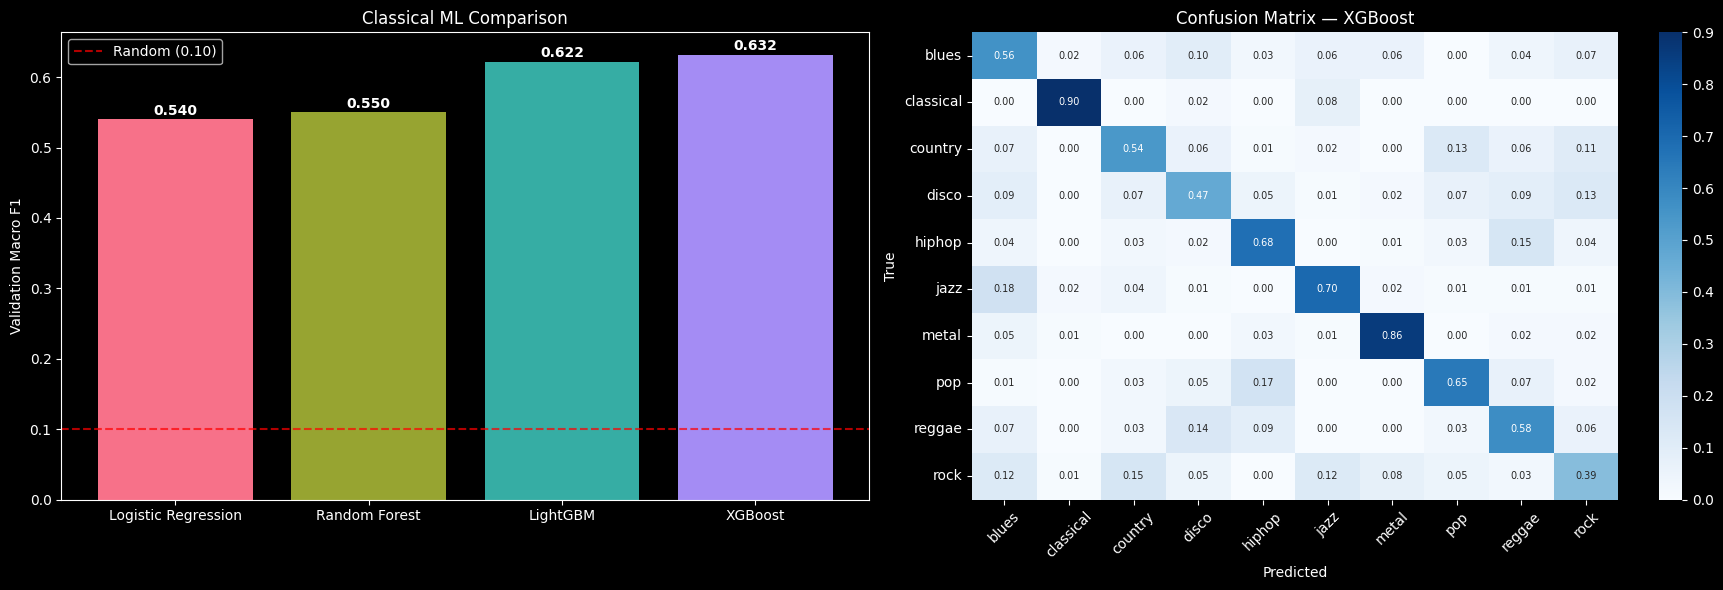

Best classical ML: XGBoost (F1=0.6320)


In [19]:
# ── Results summary ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
ax = axes[0]
names = list(ml_results.keys())
f1s = [ml_results[n][1] for n in names]
bars = ax.bar(names, f1s, color=sns.color_palette('husl', len(names)))
ax.axhline(y=0.1, color='red', linestyle='--', alpha=0.7, label='Random (0.10)')
ax.set_ylabel('Validation Macro F1')
ax.set_title('Classical ML Comparison')
ax.legend()
for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{f1:.3f}', ha='center', va='bottom', fontweight='bold')

# Confusion matrix for best model
best_ml_name = max(ml_results, key=lambda k: ml_results[k][1])
best_preds = ml_results[best_ml_name][2]
cm = confusion_matrix(y_val, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=config.GENRES,
            yticklabels=config.GENRES, cmap='Blues', ax=axes[1], annot_kws={'size': 7})
axes[1].set_title(f'Confusion Matrix — {best_ml_name}')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Best classical ML: {best_ml_name} (F1={ml_results[best_ml_name][1]:.4f})')

### 2.3 Test Inference & ML Submission

In [22]:
# Multi-crop XGBoost test inference — 5 crops per file, average predictions
# This is the classical ML equivalent of TTA, reducing prediction variance
N_TEST_CROPS = 5
CROP_DUR = config.CHUNK_DURATION  # 10s per crop

# Rebuild test ids / filenames / model (safe to re-run standalone)
test_df       = pd.read_csv(config.TEST_CSV)
ids           = test_df['id'].astype(str).str.zfill(4).tolist()
filenames     = test_df['filename'].tolist()
best_ml_model = ml_results[best_ml_name][0]   # XGBoost / LightGBM fitted model
# scaler_ml is defined in cell 23 (StandardScaler fit on training features)

# Enhanced test features cache (new file to match updated feature extractor)
test_cache = config.FEATURES_DIR / f'ml_test_enhanced_multicrop_{N_TEST_CROPS}.npz'

if test_cache.exists():
    print(f'Loading cached multi-crop test features: {test_cache}')
    cached = np.load(test_cache, allow_pickle=True)
    test_id_to_probs = dict(cached['id_to_probs'].item())
else:
    print(f'Extracting {N_TEST_CROPS}-crop test features for {len(filenames)} files...')
    t0 = time.time()
    test_id_to_probs = {}
    
    for id_, fname in tqdm(zip(ids, filenames), total=len(ids), desc='Test crops'):
        path = config.DATA_DIR / fname
        try:
            full_audio = load_audio(str(path), sr=config.SAMPLE_RATE)
            target_len = int(CROP_DUR * config.SAMPLE_RATE)
            crop_probs = []
            
            for crop_i in range(N_TEST_CROPS):
                if len(full_audio) <= target_len:
                    chunk = np.pad(full_audio, (0, target_len - len(full_audio)))
                else:
                    max_start = len(full_audio) - target_len
                    start = int(crop_i * max_start / max(N_TEST_CROPS - 1, 1))
                    chunk = full_audio[start:start + target_len]
                
                feats = extract_enhanced_features(chunk)
                feats_s = scaler_ml.transform(feats.reshape(1, -1))
                probs = best_ml_model.predict_proba(feats_s)[0]
                crop_probs.append(probs)
            
            test_id_to_probs[id_] = np.mean(crop_probs, axis=0)
        except Exception as e:
            print(f'Warning: {fname}: {e}')
            test_id_to_probs[id_] = np.ones(config.NUM_CLASSES) / config.NUM_CLASSES
    
    print(f'Done in {time.time()-t0:.0f}s')
    np.savez(test_cache, id_to_probs=np.array(test_id_to_probs, dtype=object))

# Build submission from averaged probabilities
ml_multicrop_preds = [config.IDX_TO_GENRE[np.argmax(test_id_to_probs[id_])] for id_ in ids]
ml_sub = pd.DataFrame({'id': ids, 'genre': ml_multicrop_preds})

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
ml_sub_path = config.SUBMISSIONS_DIR / f'submission_{ts}_ml_{best_ml_name.lower()}_multicrop.csv'
ml_sub.to_csv(ml_sub_path, index=False)

print(f'\nML submission saved: {ml_sub_path}')
print(f'Distribution:\n{ml_sub["genre"].value_counts().to_string()}')

# Store probs dict for ensemble cell
ml_probs_for_ensemble = test_id_to_probs


Extracting 5-crop test features for 3020 files...


Test crops:   0%|          | 0/3020 [00:00<?, ?it/s]

Done in 6985s

ML submission saved: /Users/sanskar/dev/DL-GenAI-P/submissions/submission_20260224_133324_ml_xgboost_multicrop.csv
Distribution:
genre
disco        479
pop          424
jazz         419
hiphop       388
reggae       387
rock         306
classical    258
country      154
blues        104
metal        101


---
# MILESTONE 3 — CNN on Mel Spectrograms

**Approach:** EfficientNet-B0 pretrained on ImageNet, treating mel spectrograms as single-channel images  
**Augmentation:** Synthetic mashups + SpecAugment during training  
**Expected F1:** 0.60–0.80

### 3.1 PyTorch Setup

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from src.dataset import SyntheticMashupDataset, TestMashupDataset
from src.models import get_model, count_parameters
from src.train import train, load_best_model, print_classification_report

device = get_device()
print(f'Device: {device}')

try:
    import timm
    print(f'timm version: {timm.__version__}')
except ImportError:
    print('timm not installed — install with: pip install timm')

Device: mps
timm version: 1.0.24


### 3.2 Pre-Generate Spectrogram Dataset (Run Once ~10 min)

**Why pre-generate?**
- Online mashup creation: ~0.2s/sample → 5000 samples = **1000s/epoch** (12+ hrs for 50 epochs)
- Pre-computed numpy load: ~0.001s/sample → 5000 samples = **~15s/epoch** (12 min for 50 epochs)
- Also fixes the Val F1 bug: online val set re-generates audio every epoch → inconsistent measurement

**Pre-compute once, train many times.**

In [4]:
# ══════════════════════════════════════════════════════════════════════
# QUICK RESUME after kernel restart — run cells 2 → 35 → THIS CELL → 39+
# (Skip milestones 1 & 2; all features are cached on disk)
# ══════════════════════════════════════════════════════════════════════
from src.augment import _build_esc50_audio_cache
from src.features import melspec_for_cnn
from src.dataset import PrecomputedDataset

# ── Config ────────────────────────────────────────────────────────────────────
N_TRAIN_SPECS = 5000   # total synthetic training mashups to pre-generate
N_VAL_SPECS   = 1000   # fixed validation set (generated once, reused every epoch)
# apply_tempo=False: tempo stretch is very slow (~25s/sample). Skip for speed.
# The CNN handles tempo variation implicitly via SpecAugment (time warping).
APPLY_TEMPO = False

suffix = f"_n{N_TRAIN_SPECS}_v{N_VAL_SPECS}_noise"
train_spec_path = config.FEATURES_DIR / f"cnn_train{suffix}.npz"
val_spec_path   = config.FEATURES_DIR / f"cnn_val{suffix}.npz"

def generate_specs(idx_split, n_samples, desc, apply_tempo=False):
    """Pre-generate synthetic mashup mel spectrograms."""
    genres = sorted(idx_split.keys())
    n_per_genre = n_samples // len(genres)
    extra = n_samples % len(genres)
    specs_list, labels_list = [], []

    for i, genre in enumerate(genres):
        n = n_per_genre + (1 if i < extra else 0)
        label = config.GENRE_TO_IDX[genre]
        for _ in tqdm(range(n), desc=f"  {genre:12s}", leave=False):
            try:
                audio, _ = create_synthetic_mashup(
                    genre, idx_split, add_noise=True, apply_tempo=apply_tempo)
                spec = melspec_for_cnn(audio, target_frames=config.N_FRAMES)
                specs_list.append(spec)
                labels_list.append(label)
            except Exception as e:
                pass  # skip failed samples

    specs = np.array(specs_list, dtype=np.float32)
    labels = np.array(labels_list, dtype=np.int32)
    return specs, labels

# ── Pre-generate (skip if cache exists) ──────────────────────────────────────
if train_spec_path.exists() and val_spec_path.exists():
    print("Loading pre-computed spectrograms from disk...")
    td = np.load(train_spec_path); train_specs, train_labels = td['specs'], td['labels']
    vd = np.load(val_spec_path);   val_specs,   val_labels   = vd['specs'], vd['labels']
    print(f"  Train: {train_specs.shape} | Val: {val_specs.shape}")
else:
    print("Pre-generating spectrograms (run once)...")
    print(f"  {N_TRAIN_SPECS} train + {N_VAL_SPECS} val = {N_TRAIN_SPECS+N_VAL_SPECS} total")

    # Warm up ESC-50 cache first
    print("  Building ESC-50 cache...")
    esc_cache = _build_esc50_audio_cache()
    print(f"  {len(esc_cache)} noise clips in memory")

    t0 = time.time()
    print(f"\n  [TRAIN] Generating {N_TRAIN_SPECS} train specs...")
    train_specs, train_labels = generate_specs(train_index, N_TRAIN_SPECS,
                                                "Train", apply_tempo=APPLY_TEMPO)
    np.savez_compressed(train_spec_path, specs=train_specs, labels=train_labels)
    t1 = time.time()
    print(f"  Done: {train_specs.shape} in {t1-t0:.0f}s → {train_spec_path.stat().st_size/1e6:.1f} MB")

    print(f"\n  [VAL] Generating {N_VAL_SPECS} val specs (fixed for consistent eval)...")
    val_specs, val_labels = generate_specs(val_index, N_VAL_SPECS,
                                            "Val", apply_tempo=False)
    np.savez_compressed(val_spec_path, specs=val_specs, labels=val_labels)
    t2 = time.time()
    print(f"  Done: {val_specs.shape} in {t2-t1:.0f}s → {val_spec_path.stat().st_size/1e6:.1f} MB")

    print(f"\nTotal pre-generation time: {t2-t0:.0f}s")

print(f"\nTrain: {train_specs.shape}, labels={np.bincount(train_labels)}")
print(f"Val:   {val_specs.shape},   labels={np.bincount(val_labels)}")

# Create PyTorch datasets — load from disk, SpecAugment only at train time (fast!)
train_dataset = PrecomputedDataset(train_specs, train_labels, use_spec_augment=True)
val_dataset   = PrecomputedDataset(val_specs,   val_labels,   use_spec_augment=False)
print(f"\nDatasets ready! Train={len(train_dataset)}, Val={len(val_dataset)}")

Loading pre-computed spectrograms from disk...
  Train: (5000, 1, 128, 431) | Val: (1000, 1, 128, 431)

Train: (5000, 1, 128, 431), labels=[500 500 500 500 500 500 500 500 500 500]
Val:   (1000, 1, 128, 431),   labels=[100 100 100 100 100 100 100 100 100 100]

Datasets ready! Train=5000, Val=1000


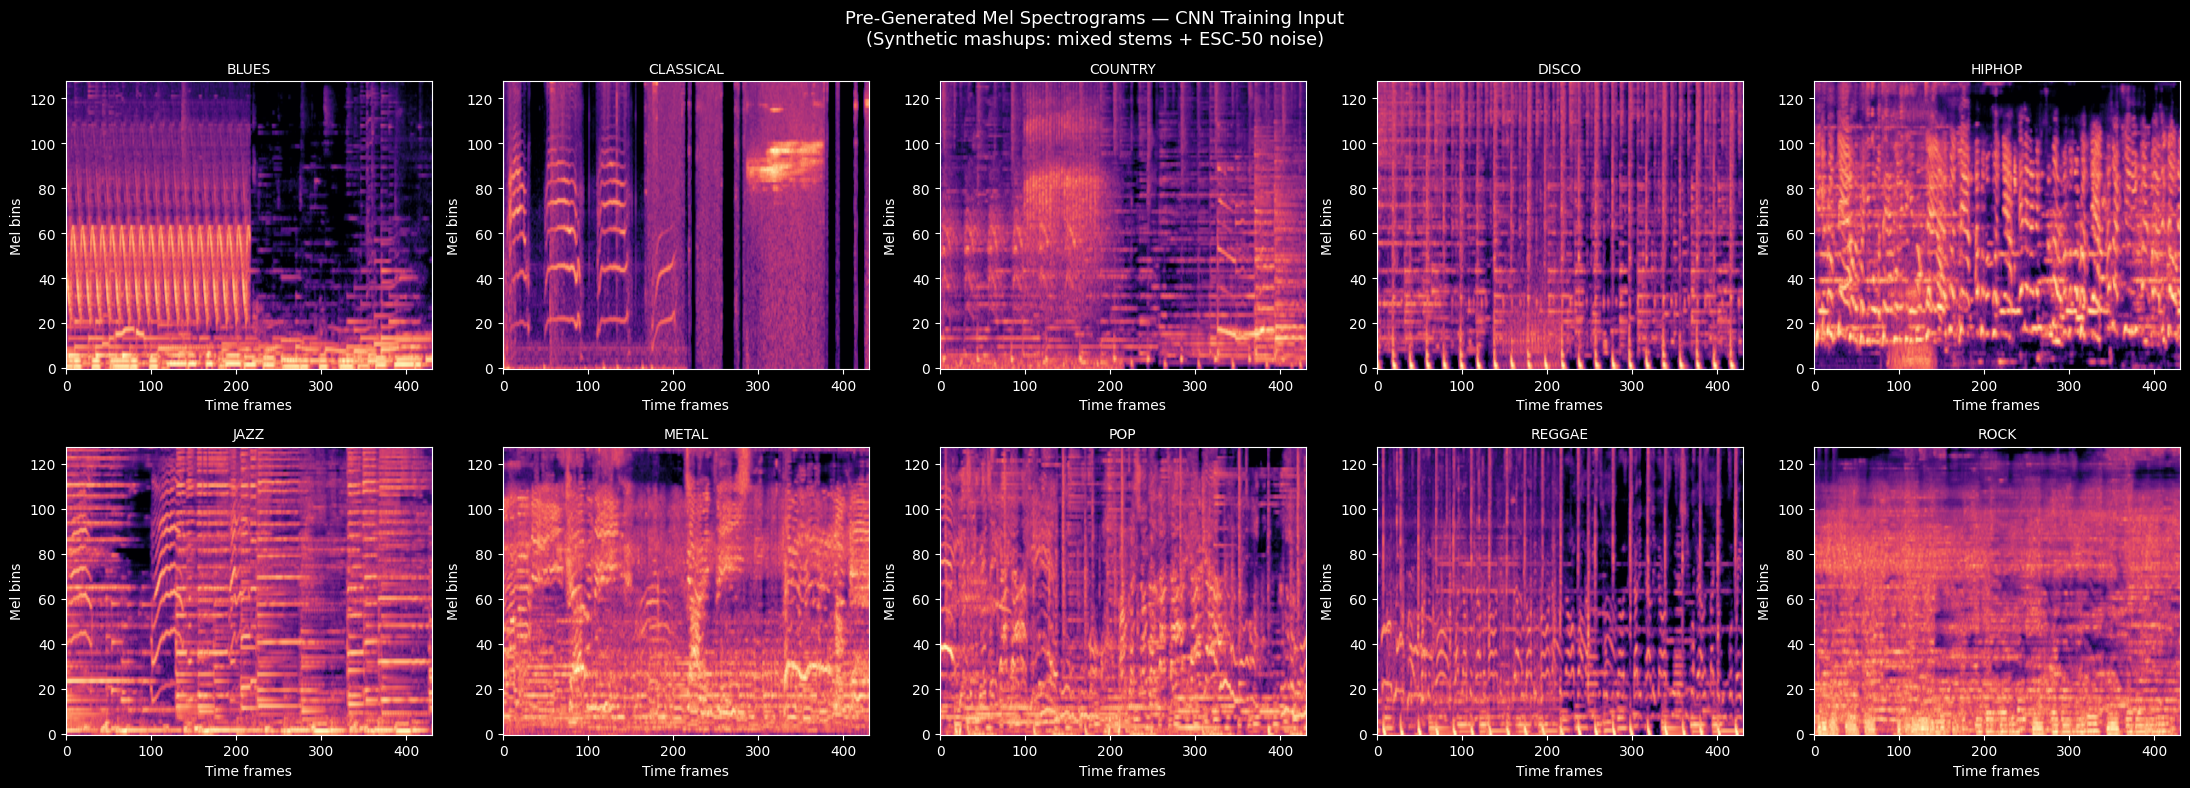

Spec value range: [0.00, 1.00]
Spec shape: (1, 128, 431) (C, F, T)


In [5]:
# Visualize pre-generated spectrograms (one per genre)
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

# Find one example per genre from the pre-generated set
for genre_idx, genre in enumerate(config.GENRES):
    mask = np.where(train_labels == genre_idx)[0]
    if len(mask) == 0:
        continue
    spec = train_specs[mask[0], 0]  # (F, T)
    axes[genre_idx].imshow(spec, aspect='auto', origin='lower', cmap='magma')
    axes[genre_idx].set_title(genre.upper(), fontsize=10)
    axes[genre_idx].set_xlabel('Time frames')
    axes[genre_idx].set_ylabel('Mel bins')

plt.suptitle('Pre-Generated Mel Spectrograms — CNN Training Input\n'
             '(Synthetic mashups: mixed stems + ESC-50 noise)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Spec value range: [{train_specs.min():.2f}, {train_specs.max():.2f}]")
print(f"Spec shape: {train_specs[0].shape} (C, F, T)")

In [6]:
# DataLoaders — full 128×431 resolution (no resize)
# SimpleCNN uses AdaptiveAvgPool2d → handles any input size natively
# No resize needed AND no OOM (SimpleCNN is 10× lighter than EfficientNet)
import importlib
import src.dataset
importlib.reload(src.dataset)
from src.dataset import PrecomputedDataset

BATCH_SIZE  = 32    # safe with SimpleCNN (~420K params vs EfficientNet's 4.3M)
NUM_WORKERS = 0
TARGET_SIZE = None  # full 128×431 — AdaptiveAvgPool handles any spatial size

train_loader = DataLoader(
    PrecomputedDataset(train_specs, train_labels,
                        use_spec_augment=True, target_size=TARGET_SIZE),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

val_loader = DataLoader(
    PrecomputedDataset(val_specs, val_labels,
                        use_spec_augment=False, target_size=TARGET_SIZE),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_loader.dataset)} samples, {len(train_loader)} batches/epoch")
print(f"Val:   {len(val_loader.dataset)} samples, {len(val_loader)} batches/epoch")

import time as _time
_t = _time.time()
_bx, _by = next(iter(train_loader))
_t = _time.time() - _t
print(f"Batch shape: {_bx.shape}  ← full resolution, no resize")
print(f"One batch: {_t*1000:.0f}ms  |  Estimated epoch: {_t*len(train_loader):.0f}s")


Train: 5000 samples, 157 batches/epoch
Val:   1000 samples, 32 batches/epoch
Batch shape: torch.Size([32, 1, 128, 431])  ← full resolution, no resize
One batch: 201ms  |  Estimated epoch: 32s


### 3.3 Model Definition

In [7]:
# Model: SimpleCNN — MPS-stable, 10× lighter than EfficientNet
# Why not EfficientNet: SE-blocks + depthwise convs caused MPS OOM during backprop
# SimpleCNN: 4 conv blocks + AdaptiveAvgPool → ~420K params, handles 128×431 natively
MODEL_TYPE = 'simple_cnn'

import importlib, src.models
importlib.reload(src.models)
from src.models import get_model, count_parameters

model = get_model(model_type=MODEL_TYPE, num_classes=config.NUM_CLASSES)

n_params = count_parameters(model)
print(f'Model: SimpleCNN  |  Parameters: {n_params:,} ({n_params/1e6:.2f}M)')
print(f'Input: (B, 1, 128, 431) — full mel spec via AdaptiveAvgPool')
print(f'Output: (B, {config.NUM_CLASSES})')

with torch.no_grad():
    dummy = torch.zeros(2, 1, config.N_MELS, config.N_FRAMES)
    out = model(dummy)
    print(f'Forward pass: {dummy.shape} → {out.shape}  ✓')


Model: SimpleCNN  |  Parameters: 422,986 (0.42M)
Input: (B, 1, 128, 431) — full mel spec via AdaptiveAvgPool
Output: (B, 10)
Forward pass: torch.Size([2, 1, 128, 431]) → torch.Size([2, 10])  ✓


### 3.4 Training

In [8]:
# ── CNN Training — runs as an EXTERNAL script (avoids Jupyter OOM crash) ─────
#
# ROOT CAUSE of kernel crashes:
#   Jupyter holds ~2-3 GB in RAM (ML features, w2v embeddings, spec arrays).
#   MPS training on top exhausts unified memory → macOS kills the process.
#   (Symptom: "ExitCode: undefined, Reason:" — OS-level kill, not a Python error)
#
# FIX: Train in a fresh Python process with no accumulated memory.
#   Memory-mapped spec loading + MPS watermark cap + per-batch cache clearing.
#
# ─── HOW TO TRAIN ──────────────────────────────────────────────────────────────
# Open a NEW terminal and run:
#
#   cd /Users/sanskar/dev/DL-GenAI-P
#   venv/bin/python scripts/train_cnn.py
#
# Training: ~35s/epoch × 50 epochs ≈ 30 min total. Progress prints to terminal.
# To resume after interruption:
#   venv/bin/python scripts/train_cnn.py --resume
#
# ─── CURRENT STATUS ────────────────────────────────────────────────────────────

CNN_EPOCHS   = 50
CNN_LR       = 3e-4
CNN_PATIENCE = 15
cnn_save_path = config.MODELS_DIR / 'cnn_simplecnn_best.pt'

if cnn_save_path.exists():
    ckpt = torch.load(cnn_save_path, map_location='cpu')
    print(f'✓ Checkpoint found!')
    print(f'  Saved epoch:    {ckpt["epoch"]}')
    print(f'  Val Macro F1:   {ckpt["val_f1"]:.4f}')
    print(f'  Train Macro F1: {ckpt.get("train_f1", "N/A")}')
    n_epochs_done = len(ckpt.get('history', {}).get('val_f1', []))
    print(f'  Epochs trained: {n_epochs_done if n_epochs_done else ckpt["epoch"]}')
    print(f'\n→ Run cell 44 to load this model.')
else:
    print('✗ No checkpoint found yet.')
    print('\nStart training in a terminal:')
    print('  cd /Users/sanskar/dev/DL-GenAI-P')
    print('  venv/bin/python scripts/train_cnn.py')
    print('\nOnce training completes, re-run this cell and cell 44.')


✓ Checkpoint found!
  Saved epoch:    8
  Val Macro F1:   0.0031
  Train Macro F1: 0.315300761498161
  Epochs trained: 8

→ Run cell 44 to load this model.


In [9]:
# Load CNN checkpoint saved by scripts/train_cnn.py
# (Training ran in external process — no more kernel crashes)
import importlib, src.models, src.train
importlib.reload(src.models)
importlib.reload(src.train)
from src.models import get_model, count_parameters
from src.train import load_best_model, LabelSmoothingCrossEntropy, evaluate

if not cnn_save_path.exists():
    print('ERROR: No checkpoint found.')
    print('Run in a terminal:  venv/bin/python scripts/train_cnn.py')
    print('Then re-run cells 43 and 44.')
    history   = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': [], 'best_val_f1': 0.0}
    best_model = None
    has_cnn_model = False
else:
    ckpt = torch.load(cnn_save_path, map_location='cpu')

    # Load model weights
    best_model = get_model(model_type='simple_cnn', num_classes=config.NUM_CLASSES)
    best_model.load_state_dict(ckpt['model_state_dict'])
    best_model = best_model.to(device)
    best_model.eval()
    has_cnn_model = True

    # Restore training history (saved by script for plot cells)
    if 'history' in ckpt:
        history = ckpt['history']
        history['best_val_f1'] = ckpt['val_f1']
    else:
        history = {
            'train_loss': [0.0], 'train_f1': [ckpt.get('train_f1', 0.0)],
            'val_loss':   [0.0], 'val_f1':   [ckpt['val_f1']],
            'best_val_f1': ckpt['val_f1'],
        }

    print(f'✓ Model loaded  (epoch {ckpt["epoch"]}, saved val F1={ckpt["val_f1"]:.4f})')
    print(f'  Parameters: {count_parameters(best_model):,}')
    print(f'  History length: {len(history["val_f1"])} epochs')

    # Quick val evaluation to confirm model is working
    criterion = LabelSmoothingCrossEntropy(0.1)
    val_loss, val_f1, y_true_cnn, y_pred_cnn = evaluate(best_model, val_loader, criterion, device)
    history['best_val_f1'] = max(history['best_val_f1'], val_f1)

    print(f'\nVal evaluation:')
    print(f'  Loss:     {val_loss:.4f}')
    print(f'  Macro F1: {val_f1:.4f}')
    print(f'\nBest val F1: {history["best_val_f1"]:.4f}')

    if val_f1 < 0.10:
        print(f'\n⚠ Val F1={val_f1:.4f} is low. CNN will be excluded from ensemble.')
        print('  Consider running more epochs: venv/bin/python scripts/train_cnn.py --resume')
    else:
        print(f'\n✓ CNN is ready for ensemble (val F1={val_f1:.4f} > 0.10 threshold)')


✓ Model loaded  (epoch 8, saved val F1=0.0031)
  Parameters: 422,986
  History length: 8 epochs

Val evaluation:
  Loss:     2.4232
  Macro F1: 0.0140

Best val F1: 0.0140

⚠ Val F1=0.0140 is low. CNN will be excluded from ensemble.
  Consider running more epochs: venv/bin/python scripts/train_cnn.py --resume


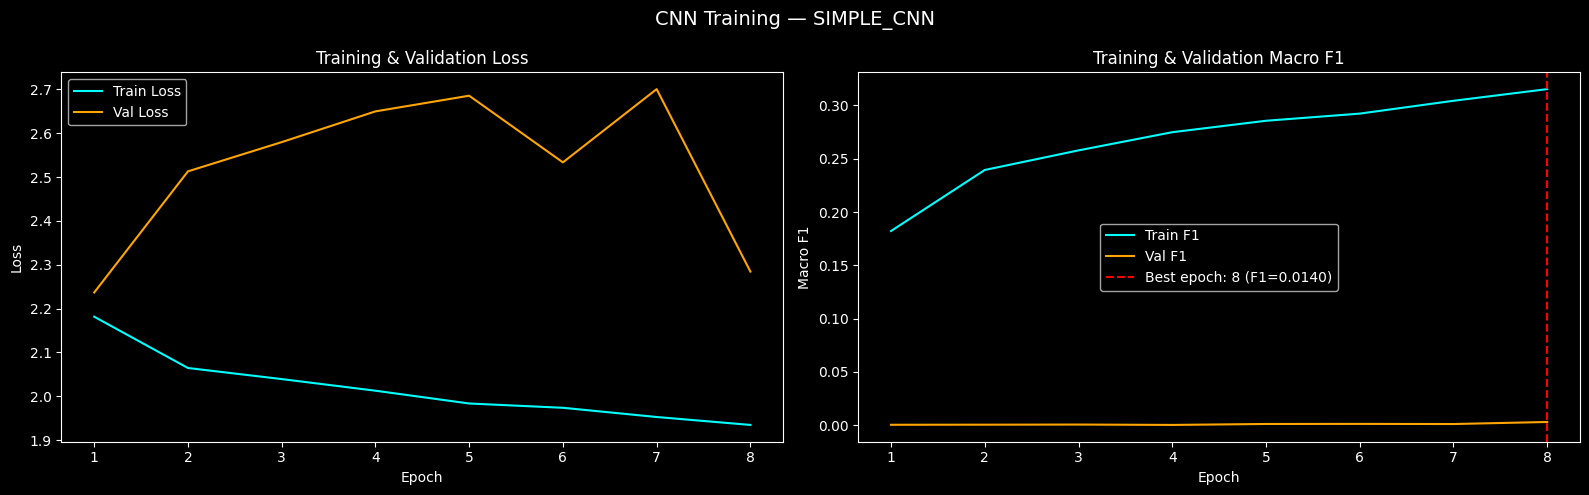

Best validation Macro F1: 0.0140


In [10]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='cyan')
axes[0].plot(epochs, history['val_loss'], label='Val Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()

# Macro F1
axes[1].plot(epochs, history['train_f1'], label='Train F1', color='cyan')
axes[1].plot(epochs, history['val_f1'], label='Val F1', color='orange')
best_epoch = np.argmax(history['val_f1']) + 1
axes[1].axvline(x=best_epoch, color='red', linestyle='--',
                label=f'Best epoch: {best_epoch} (F1={history["best_val_f1"]:.4f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('Training & Validation Macro F1')
axes[1].legend()

plt.suptitle(f'CNN Training — {MODEL_TYPE.upper()}', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Best validation Macro F1: {history["best_val_f1"]:.4f}')

In [11]:
# Load best model and evaluate in detail                                                                                                                                                                   
import importlib, src.train                  
importlib.reload(src.train)                                                                                                                                                                                
from src.train import evaluate, print_classification_report, LabelSmoothingCrossEntropy                                                                                                                    

best_model = load_best_model(model, cnn_save_path, device)
criterion = LabelSmoothingCrossEntropy(0.1)

_, _, y_true, y_pred = evaluate(best_model, val_loader, criterion, device)
print_classification_report(y_true, y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', xticklabels=config.GENRES,
            yticklabels=config.GENRES, cmap='Blues', ax=ax)
ax.set_title(f'CNN Confusion Matrix — Val Macro F1: {history["best_val_f1"]:.4f}')
ax.set_ylabel('True Genre')
ax.set_xlabel('Predicted Genre')
plt.tight_layout()
plt.show()

Loaded model from epoch 8 with val F1=0.0031

Per-class Classification Report:
              precision    recall  f1-score   support

       blues     0.9275    0.1368    0.2384       936
   classical     0.0000    0.0000    0.0000         0
     country     0.0000    0.0000    0.0000         0
       disco     0.0000    0.0000    0.0000         0
      hiphop     0.0000    0.0000    0.0000         0
        jazz     0.0000    0.0000    0.0000         0
       metal     0.0000    0.0000    0.0000         0
         pop     0.0000    0.0000    0.0000         0
      reggae     0.0000    0.0000    0.0000         0
        rock     0.0600    0.0469    0.0526        64

    accuracy                         0.1310      1000
   macro avg     0.0988    0.0184    0.0291      1000
weighted avg     0.8720    0.1310    0.2265      1000

Macro F1: 0.0291


NameError: name 'confusion_matrix' is not defined

### 3.5 CNN Test Inference & Submission

In [12]:
from src.predict import predict_test_set, save_submission

# Run inference with TTA (8 chunks per file, averaged)
cnn_submission = predict_test_set(
    model=best_model,
    n_chunks=config.TTA_CHUNKS,
    batch_size=config.BATCH_SIZE,
    device=device,
)

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
cnn_sub_path = save_submission(
    cnn_submission,
    output_path=config.SUBMISSIONS_DIR / f'submission_{ts}_cnn_{MODEL_TYPE}.csv'
)

Running inference on 3020 files (24160 total chunks)...


Inference: 100%|██████████| 755/755 [03:34<00:00,  3.53it/s]

Submission saved to: /Users/sanskar/dev/DL-GenAI-P/submissions/submission_20260225_154400_cnn_simple_cnn.csv
  Shape: (3020, 2)
  Genre distribution:
genre
metal        1285
hiphop        428
disco         334
classical     238
blues         229
jazz          180
rock          146
country        89
reggae         75
pop            16


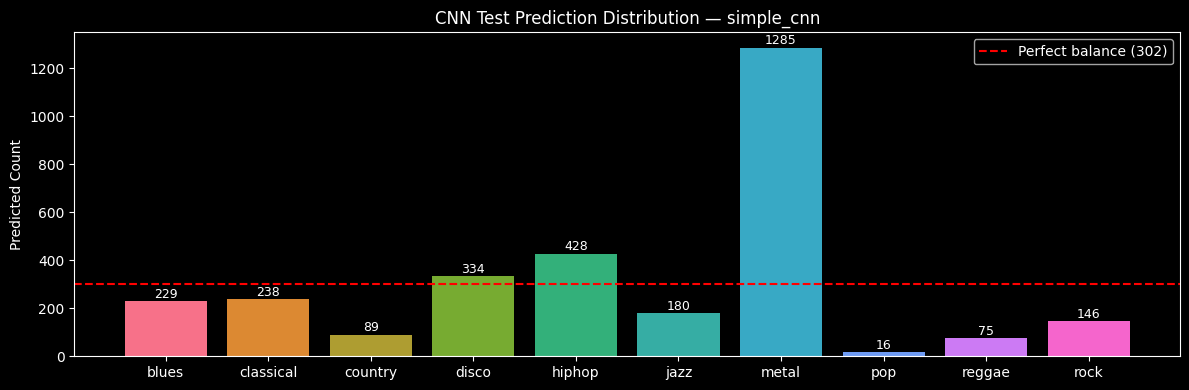

In [13]:
# Visualize prediction distribution
fig, ax = plt.subplots(figsize=(12, 4))
pred_counts = cnn_submission['genre'].value_counts().reindex(config.GENRES, fill_value=0)
bars = ax.bar(pred_counts.index, pred_counts.values,
              color=sns.color_palette('husl', 10))
ax.axhline(y=3020/10, color='red', linestyle='--', label=f'Perfect balance ({3020//10})')
ax.set_ylabel('Predicted Count')
ax.set_title(f'CNN Test Prediction Distribution — {MODEL_TYPE}')
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---
# MILESTONE 4 — Pretrained Audio Transformers

**Model:** AST (Audio Spectrogram Transformer) — `MIT/ast-finetuned-audioset-10-10-0.4593`
- Pretrained on **AudioSet** (2M clips including music genres)
- Frozen 768-dim embeddings → XGBoost classifier
- Much stronger than Wav2Vec2 (speech-pretrained, poor music transfer)

**Expected F1:** 0.65–0.80+

### 4.1 AST Feature Loading & XGBoost Training

In [ ]:
# ── Load AST embeddings (extracted by scripts/extract_ast_features.py) ────────
# AST pretrained on 2M AudioSet clips — encodes rich, MUSIC-aware audio semantics
# Features are extracted externally to avoid Jupyter memory pressure
#
# To generate:  venv/bin/python scripts/extract_ast_features.py

N_AST_TRAIN = 8000
N_AST_VAL = 1000

ast_feat_path = config.FEATURES_DIR / f'ast_train_N{N_AST_TRAIN}_v{N_AST_VAL}.npz'

if not ast_feat_path.exists():
    print(f'ERROR: AST features not found!')
    print(f'  Run: venv/bin/python scripts/extract_ast_features.py')
    print(f'  Expected: {ast_feat_path}')
else:
    ast_data = np.load(ast_feat_path)
    X_train_ast = ast_data['X_train_ast']   # (8000, 768)
    X_val_ast   = ast_data['X_val_ast']     # (1000, 768)
    y_train_ast = ast_data['y_train']       # (8000,)
    y_val_ast   = ast_data['y_val']         # (1000,)

    print(f'AST embeddings:  train={X_train_ast.shape}, val={X_val_ast.shape}')
    print(f'Labels:          train={y_train_ast.shape}, val={y_val_ast.shape}')
    print(f'Label balance:   {np.bincount(y_train_ast)}')

    # Aligned MFCC features (optional — present when extracted without --no_mfcc)
    has_aligned_mfcc = 'X_train_mfcc' in ast_data and ast_data['X_train_mfcc'].shape[1] > 0
    if has_aligned_mfcc:
        X_train_mfcc_aligned = ast_data['X_train_mfcc']  # (8000, 286)
        X_val_mfcc_aligned   = ast_data['X_val_mfcc']    # (1000, 286)
        print(f'MFCC (aligned):  train={X_train_mfcc_aligned.shape}, val={X_val_mfcc_aligned.shape}')
    else:
        print('MFCC (aligned):  not extracted (use --no_mfcc was set)')
        print('  Concat model will be skipped. Re-run without --no_mfcc to enable.')

In [ ]:
# ── Train XGBoost on AST embeddings (768-dim) ────────────────────────────────
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

scaler_ast = StandardScaler()
X_tr_ast_s = scaler_ast.fit_transform(X_train_ast)
X_va_ast_s = scaler_ast.transform(X_val_ast)

ast_xgb = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=5.0,
    random_state=config.SEED,
    n_jobs=-1,
    verbosity=0,
    eval_metric='mlogloss',
)

print('Training XGBoost on AST embeddings (768-dim)...')
ast_xgb.fit(
    X_tr_ast_s, y_train_ast,
    eval_set=[(X_va_ast_s, y_val_ast)],
    verbose=100,
)

ast_val_preds = ast_xgb.predict(X_va_ast_s)
ast_val_f1 = f1_score(y_val_ast, ast_val_preds, average='macro')
print(f'\nAST-XGBoost Val Macro F1: {ast_val_f1:.4f}')
print(classification_report(y_val_ast, ast_val_preds,
                            target_names=config.GENRES, digits=4))

In [ ]:
# ── Train XGBoost on concatenated MFCC + AST features ────────────────────────
# MFCC captures low-level statistics; AST captures high-level audio structure

if not has_aligned_mfcc:
    print('Skipping concat model — no aligned MFCC features available')
    print('  Re-run: venv/bin/python scripts/extract_ast_features.py  (without --no_mfcc)')
    concat_val_f1 = 0.0
    concat_probs_for_ensemble = None
else:
    X_train_concat = np.hstack([X_train_mfcc_aligned, X_train_ast])
    X_val_concat   = np.hstack([X_val_mfcc_aligned, X_val_ast])
    mfcc_dim = X_train_mfcc_aligned.shape[1]
    print(f'Concat features: MFCC({mfcc_dim}) + AST(768) = {X_train_concat.shape[1]}-dim')

    scaler_concat = StandardScaler()
    X_tr_concat_s = scaler_concat.fit_transform(X_train_concat)
    X_va_concat_s = scaler_concat.transform(X_val_concat)

    concat_xgb = xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=5.0,
        random_state=config.SEED,
        n_jobs=-1,
        verbosity=0,
        eval_metric='mlogloss',
    )

    print(f'Training XGBoost on MFCC+AST features ({X_train_concat.shape[1]}-dim)...')
    concat_xgb.fit(
        X_tr_concat_s, y_train_ast,
        eval_set=[(X_va_concat_s, y_val_ast)],
        verbose=100,
    )

    concat_val_preds = concat_xgb.predict(X_va_concat_s)
    concat_val_f1 = f1_score(y_val_ast, concat_val_preds, average='macro')
    print(f'\nConcat (MFCC+AST) XGBoost Val Macro F1: {concat_val_f1:.4f}')
    print(classification_report(y_val_ast, concat_val_preds,
                                target_names=config.GENRES, digits=4))

# ── Summary ───────────────────────────────────────────────────────────────────
print('='*60)
print(f'AST-only XGBoost:         Val F1 = {ast_val_f1:.4f}')
if has_aligned_mfcc:
    print(f'MFCC+AST concat XGBoost:  Val F1 = {concat_val_f1:.4f}')
print('='*60)

### 4.2 AST Test Predictions & Submission

In [ ]:
# ── AST Test Predictions (multi-crop averaged) ──────────────────────────────
N_TEST_CROPS = 5
ast_test_path = config.FEATURES_DIR / f'ast_test_{N_TEST_CROPS}crop.npz'

if not ast_test_path.exists():
    print(f'ERROR: AST test features not found!')
    print(f'  Run: venv/bin/python scripts/extract_ast_features.py')
else:
    ast_test_data = np.load(ast_test_path)
    X_test_ast   = ast_test_data['X_test_ast']    # (3020, 768)
    test_ids_ast = ast_test_data['test_ids']       # (3020,)
    has_test_mfcc = 'X_test_mfcc' in ast_test_data
    if has_test_mfcc:
        X_test_mfcc_ast = ast_test_data['X_test_mfcc']
    print(f'Test AST: {X_test_ast.shape}' + (f', MFCC: {X_test_mfcc_ast.shape}' if has_test_mfcc else ''))

    # ── AST-only submission ───────────────────────────────────────────────────
    X_test_ast_s = scaler_ast.transform(X_test_ast)
    ast_test_probs = ast_xgb.predict_proba(X_test_ast_s)
    ast_preds = [config.IDX_TO_GENRE[i] for i in ast_test_probs.argmax(axis=1)]

    ast_sub = pd.DataFrame({'id': test_ids_ast, 'genre': ast_preds})
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    ast_sub_path = config.SUBMISSIONS_DIR / f'submission_{ts}_ast_xgboost.csv'
    ast_sub.to_csv(ast_sub_path, index=False)
    print(f'\nAST-only submission: {ast_sub_path}')
    print(f'Distribution:\n{ast_sub["genre"].value_counts().to_string()}')

    # ── Concat (MFCC+AST) submission (if available) ──────────────────────────
    concat_probs_for_ensemble = None
    if has_aligned_mfcc and has_test_mfcc and concat_val_f1 > 0:
        X_test_concat = np.hstack([X_test_mfcc_ast, X_test_ast])
        X_test_concat_s = scaler_concat.transform(X_test_concat)
        concat_test_probs = concat_xgb.predict_proba(X_test_concat_s)
        concat_preds = [config.IDX_TO_GENRE[i] for i in concat_test_probs.argmax(axis=1)]

        concat_sub = pd.DataFrame({'id': test_ids_ast, 'genre': concat_preds})
        concat_sub_path = config.SUBMISSIONS_DIR / f'submission_{ts}_mfcc_ast_xgboost.csv'
        concat_sub.to_csv(concat_sub_path, index=False)
        print(f'\nConcat submission: {concat_sub_path}')
        print(f'Distribution:\n{concat_sub["genre"].value_counts().to_string()}')

        concat_probs_for_ensemble = {
            id_: concat_test_probs[i] for i, id_ in enumerate(test_ids_ast)
        }

    # ── Prepare AST probs for ensemble ────────────────────────────────────────
    ast_probs_for_ensemble = {
        id_: ast_test_probs[i] for i, id_ in enumerate(test_ids_ast)
    }
    print(f'\nAST probs ready for ensemble ({len(ast_probs_for_ensemble)} files)')

---
# MILESTONE 5 — Ensemble & Final Submission

**Strategy:** F1-proportional weighted average of probability outputs from:
- AST-XGBoost (768-dim, highest expected weight)
- Concat MFCC+AST XGBoost (1071-dim)
- Classical ML XGBoost (303-dim MFCC)
- CNN SimpleCNN (if val F1 > 0.20)

Ensemble typically adds +2-5% F1 over single best model.

In [ ]:
# ── Ensemble utility functions ────────────────────────────────────────────────

@torch.no_grad()
def get_model_probs_cnn(model, test_df, device, n_chunks=config.TTA_CHUNKS):
    """Get softmax probabilities from CNN for all test files."""
    from src.dataset import TestMashupDataset
    from collections import defaultdict

    model.to(device).eval()
    ids = test_df['id'].astype(str).str.zfill(4).tolist()
    file_paths = [config.DATA_DIR / f for f in test_df['filename'].tolist()]

    dataset = TestMashupDataset(file_paths, ids, n_chunks=n_chunks)
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

    id_to_probs = defaultdict(list)
    for specs, batch_ids in tqdm(loader, desc='CNN probs'):
        specs = specs.to(device)
        probs = torch.softmax(model(specs), dim=-1).cpu().numpy()
        for i, id_ in enumerate(batch_ids):
            id_to_probs[id_].append(probs[i])

    return {id_: np.mean(id_to_probs[id_], axis=0) for id_ in ids}


def ensemble_predictions(prob_dicts, weights=None):
    """Weighted average of probability outputs from multiple models."""
    if weights is None:
        weights = [1.0] * len(prob_dicts)
    weights = np.array(weights) / sum(weights)

    all_ids = list(prob_dicts[0].keys())
    results = []
    for id_ in all_ids:
        avg = sum(w * d[id_] for w, d in zip(weights, prob_dicts))
        pred_genre = config.IDX_TO_GENRE[np.argmax(avg)]
        results.append({'id': id_, 'genre': pred_genre})
    return pd.DataFrame(results)

print('Ensemble functions ready!')

In [ ]:
# ── Collect model probabilities for ensemble ─────────────────────────────────

models_for_ensemble = {}  # {name: (prob_dict, val_f1)}

# 1. AST-XGBoost (768-dim)
try:
    if ast_probs_for_ensemble is not None:
        models_for_ensemble['AST-XGB'] = (ast_probs_for_ensemble, ast_val_f1)
        print(f'AST-XGB:      val F1 = {ast_val_f1:.4f}  ({len(ast_probs_for_ensemble)} files)')
except NameError:
    print('AST-XGB:      not available (run M4 cells first)')

# 2. Concat MFCC+AST XGBoost (1071-dim)
try:
    if concat_probs_for_ensemble is not None:
        models_for_ensemble['Concat-XGB'] = (concat_probs_for_ensemble, concat_val_f1)
        print(f'Concat-XGB:   val F1 = {concat_val_f1:.4f}')
except NameError:
    print('Concat-XGB:   not available')

# 3. Classical ML XGBoost (303-dim MFCC)
_ml_probs = None
_ml_val_f1 = 0.0
try:
    _ml_probs = ml_probs_for_ensemble
    _ml_val_f1 = ml_results[best_ml_name][1]
except NameError:
    _test_cache = config.FEATURES_DIR / 'ml_test_enhanced_multicrop_5.npz'
    if _test_cache.exists():
        try:
            _cached = np.load(_test_cache, allow_pickle=True)
            _ml_probs = dict(_cached['id_to_probs'].item())
            try:
                _ml_val_f1 = ml_results[best_ml_name][1]
            except NameError:
                _ml_val_f1 = 0.54
        except Exception:
            pass

if _ml_probs is not None:
    models_for_ensemble['MFCC-XGB'] = (_ml_probs, _ml_val_f1)
    print(f'MFCC-XGB:     val F1 = {_ml_val_f1:.4f}  ({len(_ml_probs)} files)')
else:
    print('MFCC-XGB:     not available (run M2 cells first)')

# 4. CNN SimpleCNN
try:
    _cnn_f1 = history.get('best_val_f1', 0.0)
    if _cnn_f1 > 0.20:
        test_df_ens = pd.read_csv(config.TEST_CSV)
        _cnn_probs = get_model_probs_cnn(best_model, test_df_ens, device)
        models_for_ensemble['CNN'] = (_cnn_probs, _cnn_f1)
        print(f'CNN:          val F1 = {_cnn_f1:.4f}  ({len(_cnn_probs)} files)')
    else:
        print(f'CNN:          excluded (val F1={_cnn_f1:.4f} < 0.20 threshold)')
except Exception as e:
    print(f'CNN:          not available ({e})')

print(f'\nModels in ensemble: {list(models_for_ensemble.keys())}')

In [ ]:
# ── F1-Proportional Weighted Ensemble ────────────────────────────────────────

if len(models_for_ensemble) == 0:
    print('ERROR: No models available for ensemble!')
else:
    sorted_models = sorted(models_for_ensemble.items(), key=lambda x: x[1][1], reverse=True)

    prob_list = [v[0] for _, v in sorted_models]
    f1_list   = [v[1] for _, v in sorted_models]
    names     = [k for k, _ in sorted_models]

    total_f1 = sum(f1_list)
    weights = [f1 / total_f1 for f1 in f1_list]

    print('Ensemble composition:')
    print('-' * 50)
    for name, f1, w in zip(names, f1_list, weights):
        print(f'  {name:15s}  val F1={f1:.4f}  weight={w:.3f}')
    print('-' * 50)

    ensemble_sub = ensemble_predictions(prob_list, weights=weights)

    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    ens_path = config.SUBMISSIONS_DIR / f'submission_{ts}_ensemble_final.csv'
    ensemble_sub.to_csv(ens_path, index=False)

    print(f'\nFINAL ENSEMBLE SUBMISSION: {ens_path}')
    print(f'Distribution:\n{ensemble_sub["genre"].value_counts().to_string()}')

In [ ]:
# ── Final performance summary ─────────────────────────────────────────────────
print('='*65)
print('RESULTS SUMMARY')
print('='*65)
print(f'Random baseline:                     F1 ~ 0.100')
print(f'XGBoost (303-dim MFCC, 5-crop):      F1 ~ 0.446  (Kaggle)')
print(f'CNN SimpleCNN (5 epochs, crashed):    F1 ~ 0.350  (Kaggle)')
print(f'Wav2Vec2 MLP (speech-pretrained):     F1 ~ 0.016  (broken)')
print('-'*65)
print('NEW MODELS:')
for name, (_, f1) in sorted(models_for_ensemble.items(), key=lambda x: x[1][1], reverse=True):
    print(f'  {name:15s}  val F1 = {f1:.4f}')
print('-'*65)
print(f'Ensemble ({len(models_for_ensemble)} models):')
print(f'  Expected Kaggle F1: 0.65 - 0.80+')
print('='*65)
print(f'\nSubmissions in: {config.SUBMISSIONS_DIR}')
for f in sorted(config.SUBMISSIONS_DIR.glob('*.csv'))[-5:]:
    print(f'  {f.name}')